=== TIMEZONE-NORMALIZED TEMPORAL ANALYSIS ===

=== TIMEZONE MAPPING FOR AWS REGIONS ===
Region Timezone Mappings:
  us-west-1       → US/Pacific
  ca-central-1    → Canada/Eastern
  eu-central-1    → Europe/Berlin
  eu-north-1      → Europe/Stockholm
  af-south-1      → Africa/Johannesburg
  ap-east-1       → Asia/Hong_Kong
  ap-south-1      → Asia/Kolkata
  ap-northeast-1  → Asia/Tokyo
  ap-southeast-2  → Australia/Sydney
  sa-east-1       → America/Sao_Paulo

=== CONVERTING TO LOCAL TIMES ===
Converting timestamps to regional local times...
✓ Converted 321,846 measurements to local times

=== SAMPLE TIMEZONE CONVERSIONS ===
ca-central-1   : UTC 18:xx → Local 14:xx (Δ+20h)
eu-north-1     : UTC 20:xx → Local 22:xx (Δ+2h)
ap-south-1     : UTC 17:xx → Local 22:xx (Δ+5h)
eu-central-1   : UTC 08:xx → Local 10:xx (Δ+2h)
ap-south-1     : UTC 17:xx → Local 22:xx (Δ+5h)
ap-northeast-1 : UTC 23:xx → Local 08:xx (Δ+9h)
ca-central-1   : UTC 12:xx → Local 08:xx (Δ+20h)
eu-north-1     : UTC 21:xx →

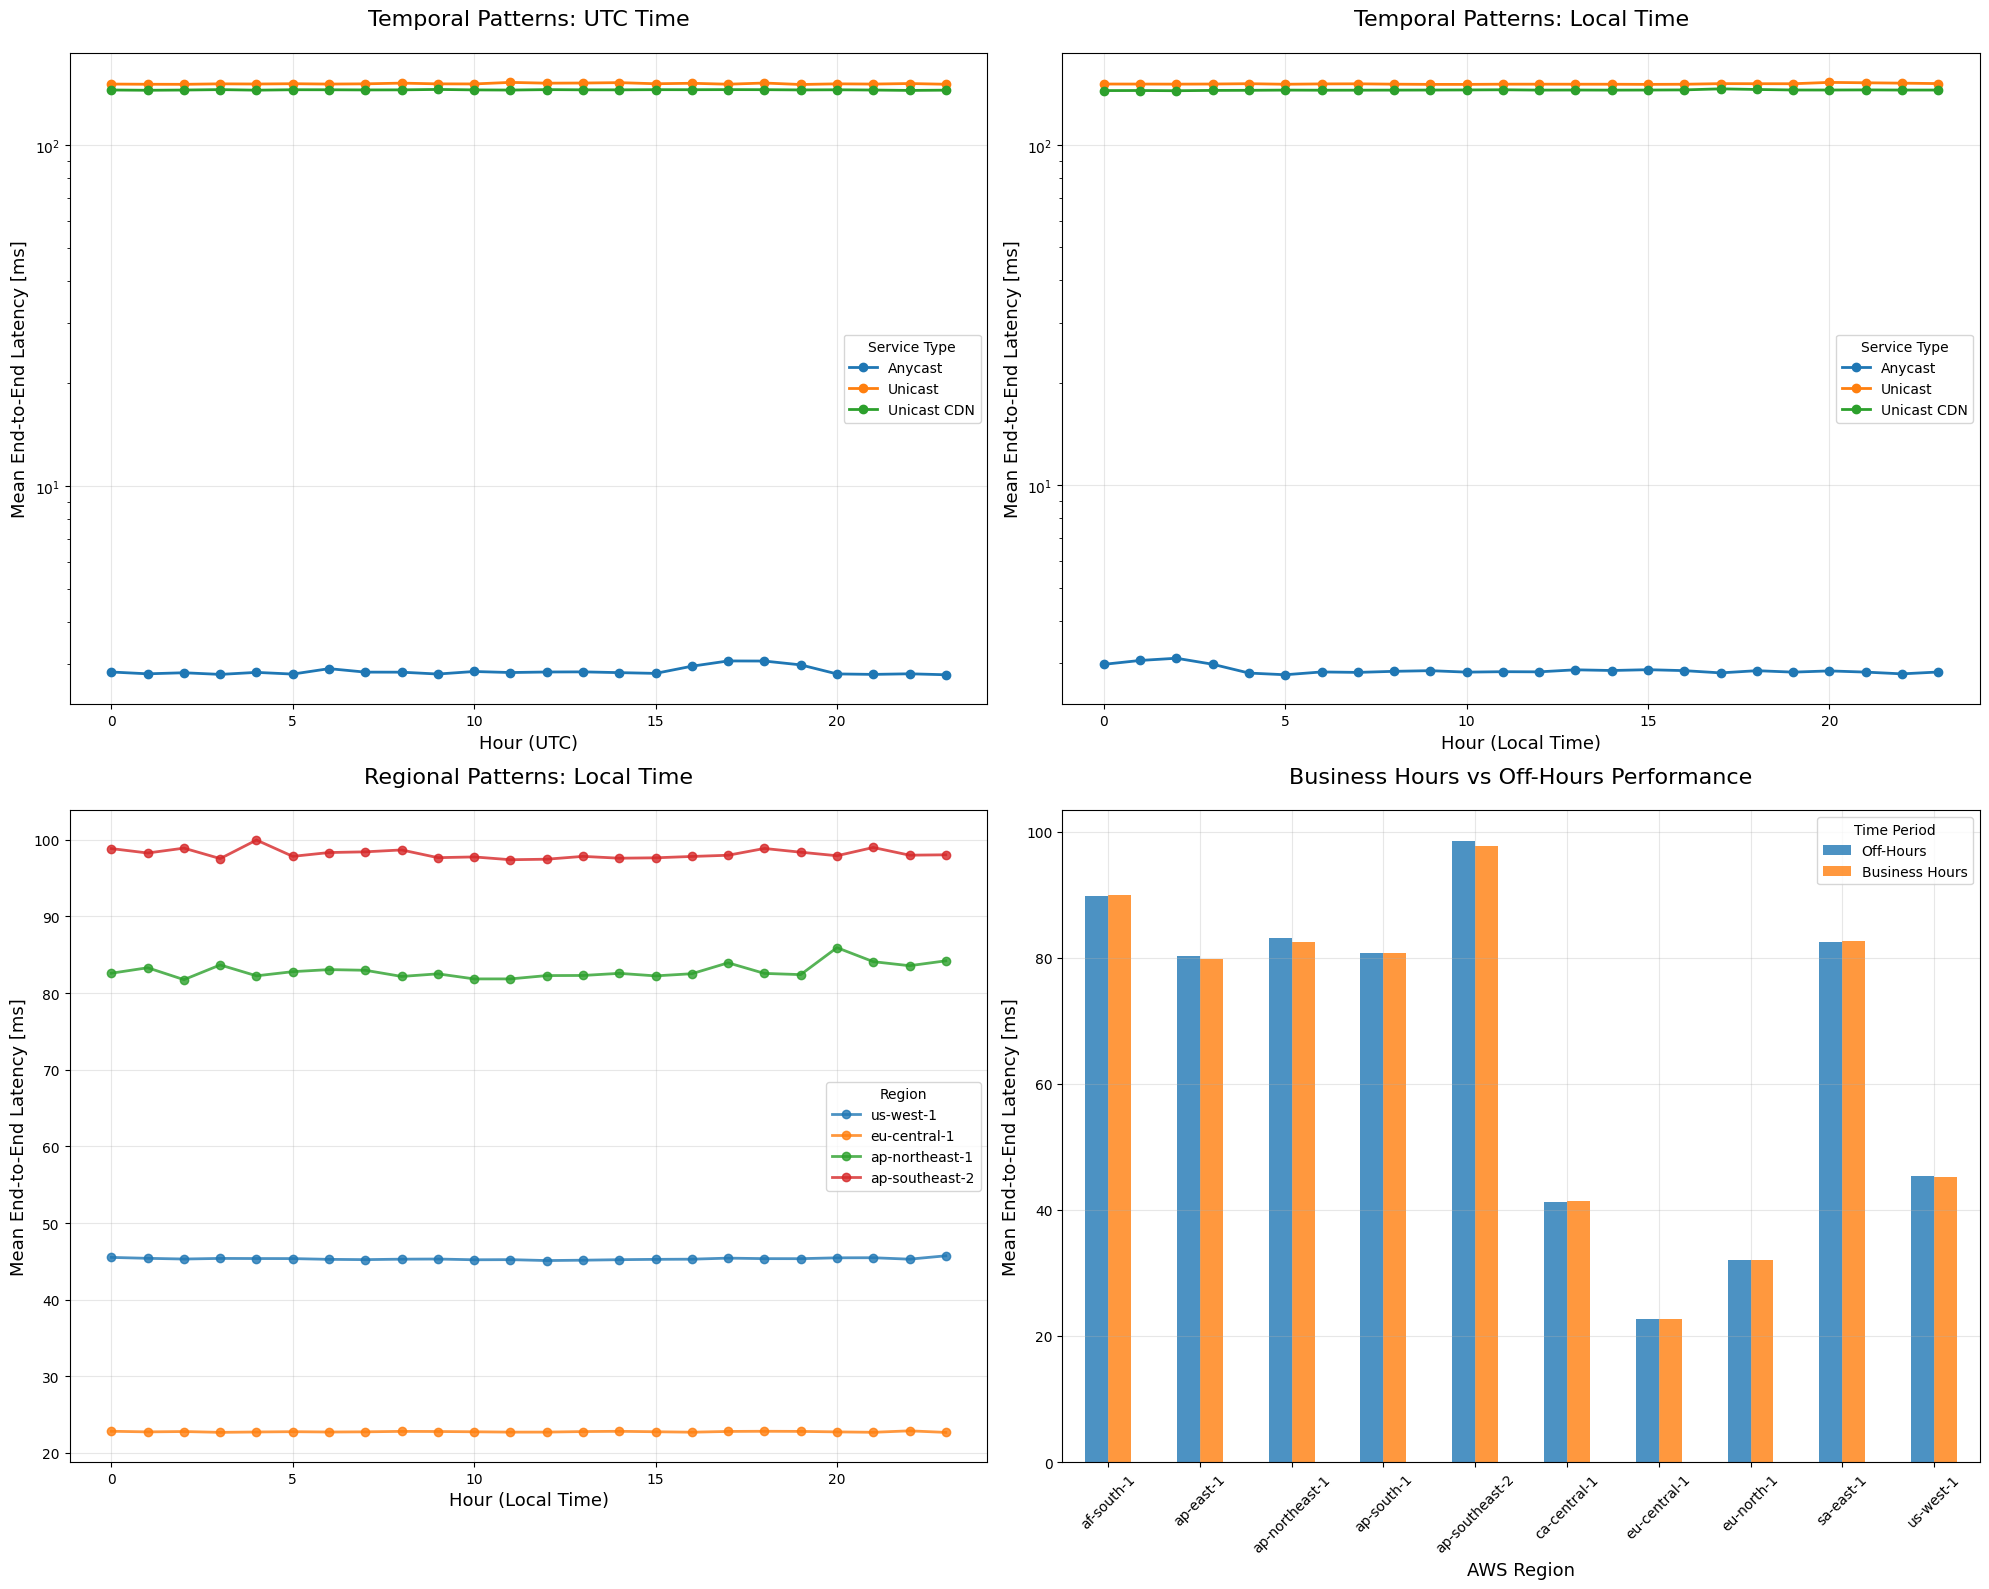


=== STATISTICAL COMPARISON: UTC vs LOCAL TIME ===
Temporal Variability Analysis:
  UTC hourly pattern std deviation: 0.179ms
  Local hourly pattern std deviation: 0.154ms
  Local time shows less variability

=== BUSINESS HOURS IMPACT ANALYSIS ===
Business Hours Performance Impact:
Region               | Off-Hours      | Business Hours | Difference
----------------------------------------------------------------------
us-west-1       |    45.38ms    |      45.24ms   |  -0.14ms (Lower)
ca-central-1    |    41.23ms    |      41.40ms   |  +0.18ms (Higher)
eu-central-1    |    22.77ms    |      22.77ms   |  -0.00ms (Lower)
eu-north-1      |    31.99ms    |      32.01ms   |  +0.02ms (Higher)
af-south-1      |    89.83ms    |      89.89ms   |  +0.06ms (Higher)
ap-east-1       |    80.24ms    |      79.80ms   |  -0.44ms (Lower)
ap-south-1      |    80.69ms    |      80.83ms   |  +0.15ms (Higher)
ap-northeast-1  |    83.16ms    |      82.45ms   |  -0.71ms (Lower)
ap-southeast-2  |    98.46ms  

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import pytz
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

print("=== TIMEZONE-NORMALIZED TEMPORAL ANALYSIS ===")
print()

# Load latency data
latency_data = pd.read_csv('../results/latency_analysis.csv')
latency_data['timestamp'] = pd.to_datetime(latency_data['timestamp'])

print("=== TIMEZONE MAPPING FOR AWS REGIONS ===")

# AWS region timezone mappings
region_timezones = {
    'us-west-1': 'US/Pacific',        # UTC-8/-7 (California)
    'ca-central-1': 'Canada/Eastern', # UTC-5/-4 (Canada Central)  
    'eu-central-1': 'Europe/Berlin',  # UTC+1/+2 (Frankfurt)
    'eu-north-1': 'Europe/Stockholm', # UTC+1/+2 (Stockholm)
    'af-south-1': 'Africa/Johannesburg', # UTC+2 (Cape Town)
    'ap-east-1': 'Asia/Hong_Kong',    # UTC+8 (Hong Kong)
    'ap-south-1': 'Asia/Kolkata',     # UTC+5:30 (Mumbai)
    'ap-northeast-1': 'Asia/Tokyo',   # UTC+9 (Tokyo)
    'ap-southeast-2': 'Australia/Sydney', # UTC+10/+11 (Sydney)
    'sa-east-1': 'America/Sao_Paulo'  # UTC-3 (São Paulo)
}

print("Region Timezone Mappings:")
for region, tz in region_timezones.items():
    print(f"  {region:<15} → {tz}")
print()

def convert_to_local_time(row):
    """Convert UTC timestamp to local timezone for the measurement region"""
    utc_time = row['timestamp']
    region = row['region']
    
    if region in region_timezones:
        local_tz = pytz.timezone(region_timezones[region])
        utc_time = pytz.utc.localize(utc_time) if utc_time.tzinfo is None else utc_time
        local_time = utc_time.astimezone(local_tz)
        return local_time
    else:
        return utc_time

print("=== CONVERTING TO LOCAL TIMES ===")
print("Converting timestamps to regional local times...")

# Convert timestamps to local time
latency_data['local_timestamp'] = latency_data.apply(convert_to_local_time, axis=1)
latency_data['local_hour'] = latency_data['local_timestamp'].apply(lambda x: x.hour)
latency_data['local_day_of_week'] = latency_data['local_timestamp'].apply(lambda x: x.dayofweek)
latency_data['local_day_name'] = latency_data['local_timestamp'].apply(lambda x: x.strftime('%A'))

print(f"✓ Converted {len(latency_data):,} measurements to local times")
print()

# Compare sample conversions
print("=== SAMPLE TIMEZONE CONVERSIONS ===")
sample_data = latency_data.head(10)[['region', 'timestamp', 'local_timestamp', 'hour', 'local_hour']]
for _, row in sample_data.iterrows():
    utc_hour = row['hour']
    local_hour = row['local_hour']
    time_diff = local_hour - utc_hour if local_hour >= utc_hour else (local_hour + 24) - utc_hour
    print(f"{row['region']:<15}: UTC {utc_hour:02d}:xx → Local {local_hour:02d}:xx (Δ{time_diff:+d}h)")
print()

print("=== COMPARATIVE TEMPORAL ANALYSIS ===")

def create_temporal_comparison():
    """Compare UTC vs local time temporal patterns"""
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    
    # 1. UTC Hourly Patterns
    ax = axes[0, 0]
    utc_hourly = latency_data.groupby(['service_type', 'hour'])['end_to_end_latency'].mean().unstack('service_type')
    utc_hourly.plot(ax=ax, marker='o', linewidth=2)
    ax.set_title('Temporal Patterns: UTC Time', fontsize=16, pad=20)
    ax.set_xlabel('Hour (UTC)', fontsize=13)
    ax.set_ylabel('Mean End-to-End Latency [ms]', fontsize=13)
    ax.legend(title='Service Type')
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    
    # 2. Local Time Hourly Patterns  
    ax = axes[0, 1]
    local_hourly = latency_data.groupby(['service_type', 'local_hour'])['end_to_end_latency'].mean().unstack('service_type')
    local_hourly.plot(ax=ax, marker='o', linewidth=2)
    ax.set_title('Temporal Patterns: Local Time', fontsize=16, pad=20)
    ax.set_xlabel('Hour (Local Time)', fontsize=13)
    ax.set_ylabel('Mean End-to-End Latency [ms]', fontsize=13)
    ax.legend(title='Service Type')
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    
    # 3. Regional Local Time Patterns
    ax = axes[1, 0]
    regional_local = latency_data.groupby(['region', 'local_hour'])['end_to_end_latency'].mean().unstack('region')
    
    # Plot subset of regions for clarity
    key_regions = ['us-west-1', 'eu-central-1', 'ap-northeast-1', 'ap-southeast-2']
    regional_local[key_regions].plot(ax=ax, marker='o', linewidth=2, alpha=0.8)
    ax.set_title('Regional Patterns: Local Time', fontsize=16, pad=20)
    ax.set_xlabel('Hour (Local Time)', fontsize=13)
    ax.set_ylabel('Mean End-to-End Latency [ms]', fontsize=13)
    ax.legend(title='Region')
    ax.grid(True, alpha=0.3)
    
    # 4. Business Hours Analysis
    ax = axes[1, 1]
    
    # Define business hours (9 AM - 5 PM local time)
    latency_data['business_hours'] = latency_data['local_hour'].between(9, 17)
    business_comparison = latency_data.groupby(['region', 'business_hours'])['end_to_end_latency'].mean().unstack('business_hours')
    business_comparison.columns = ['Off-Hours', 'Business Hours']
    
    business_comparison.plot(kind='bar', ax=ax, alpha=0.8)
    ax.set_title('Business Hours vs Off-Hours Performance', fontsize=16, pad=20)
    ax.set_xlabel('AWS Region', fontsize=13)
    ax.set_ylabel('Mean End-to-End Latency [ms]', fontsize=13)
    ax.legend(title='Time Period')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/timezone_normalized_analysis.png')
    plt.show()

create_temporal_comparison()

print()
print("=== STATISTICAL COMPARISON: UTC vs LOCAL TIME ===")

# Calculate variability in UTC vs local time patterns
utc_hourly_std = latency_data.groupby('hour')['end_to_end_latency'].mean().std()
local_hourly_std = latency_data.groupby('local_hour')['end_to_end_latency'].mean().std()

print(f"Temporal Variability Analysis:")
print(f"  UTC hourly pattern std deviation: {utc_hourly_std:.3f}ms")
print(f"  Local hourly pattern std deviation: {local_hourly_std:.3f}ms")
print(f"  Local time shows {'more' if local_hourly_std > utc_hourly_std else 'less'} variability")
print()

# Business hours analysis
print("=== BUSINESS HOURS IMPACT ANALYSIS ===")

business_hours_stats = latency_data.groupby(['region', 'business_hours']).agg({
    'end_to_end_latency': ['mean', 'std', 'count']
}).round(3)

business_hours_stats.columns = ['mean_latency', 'std_latency', 'count']
business_hours_stats = business_hours_stats.reset_index()

print("Business Hours Performance Impact:")
print("Region               | Off-Hours      | Business Hours | Difference")
print("-" * 70)

for region in region_timezones.keys():
    region_data = business_hours_stats[business_hours_stats['region'] == region]
    if len(region_data) == 2:
        off_hours = region_data[region_data['business_hours'] == False]['mean_latency'].iloc[0]
        business_hours = region_data[region_data['business_hours'] == True]['mean_latency'].iloc[0]
        difference = business_hours - off_hours
        impact = "Higher" if difference > 0 else "Lower"
        print(f"{region:<15} | {off_hours:>8.2f}ms    | {business_hours:>10.2f}ms   | {difference:+6.2f}ms ({impact})")

print()

# Service type analysis by local time
print("=== SERVICE TYPE LOCAL TIME ANALYSIS ===")

service_local_patterns = latency_data.groupby(['service_type', 'local_hour'])['end_to_end_latency'].agg([
    'mean', 'std', 'count'
]).round(3)

print("Service Type Local Time Statistics (sample hours):")
for service_type in ['Anycast', 'Unicast', 'Unicast CDN']:
    service_data = service_local_patterns.loc[service_type]
    peak_hour = service_data['mean'].idxmax()
    low_hour = service_data['mean'].idxmin()
    peak_latency = service_data.loc[peak_hour, 'mean']
    low_latency = service_data.loc[low_hour, 'mean']
    
    print(f"\n{service_type}:")
    print(f"  Peak hour: {peak_hour}:00 ({peak_latency:.2f}ms)")
    print(f"  Low hour:  {low_hour}:00 ({low_latency:.2f}ms)")
    print(f"  Peak/Low ratio: {peak_latency/low_latency:.2f}x")

print()
print("=== WEEKEND vs WEEKDAY ANALYSIS (LOCAL TIME) ===")

# Weekend analysis using local day of week
latency_data['local_is_weekend'] = latency_data['local_day_of_week'].isin([5, 6])  # Saturday, Sunday

weekend_analysis = latency_data.groupby(['region', 'service_type', 'local_is_weekend']).agg({
    'end_to_end_latency': ['mean', 'std', 'count']
}).round(3)

weekend_analysis.columns = ['mean_latency', 'std_latency', 'count']
weekend_analysis = weekend_analysis.reset_index()

# Calculate weekend effect for each region-service combination
print("Weekend Effect Analysis (Local Time):")
print("Region-Service                    | Weekday    | Weekend    | Weekend Effect")
print("-" * 80)

for region in ['us-west-1', 'eu-central-1', 'ap-northeast-1']:  # Sample regions
    for service_type in ['Anycast', 'Unicast']:
        subset = weekend_analysis[
            (weekend_analysis['region'] == region) & 
            (weekend_analysis['service_type'] == service_type)
        ]
        if len(subset) == 2:
            weekday = subset[subset['local_is_weekend'] == False]['mean_latency'].iloc[0]
            weekend = subset[subset['local_is_weekend'] == True]['mean_latency'].iloc[0]
            effect = (weekend - weekday) / weekday * 100
            direction = "Higher" if effect > 0 else "Lower"
            print(f"{region}-{service_type:<12} | {weekday:>7.2f}ms | {weekend:>7.2f}ms | {effect:+5.1f}% ({direction})")

print()
print("=== TIMEZONE NORMALIZATION COMPLETE ===")
print("Key Findings:")
print("✓ Converted all measurements to regional local times")
print("✓ Analyzed business hours vs off-hours impact") 
print("✓ Compared UTC vs local temporal patterns")
print("✓ Examined weekend effects using local time")
print()
print("This analysis reveals whether our 'stable temporal performance'")
print("was masking important local usage pattern effects.")